# Customer Churn Prediction using Machine Learning
### PROJECT INTRODUCTION

Customer churn prediction is one of the most important machine learning
applications in the telecommunication industry.

The objective of this project is to predict whether a customer is likely
to leave the telecom service based on demographic information,
subscription details, and billing history.

This project demonstrates the complete Machine Learning workflow
including:

• Data Cleaning
• Exploratory Data Analysis (EDA)
• Feature Engineering
• Data Preprocessing
• Model Building
• Model Evaluation

Target Variable:
Churn

Yes = Customer Left
No  = Customer Stayed

## Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer

## Load Dataset

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

## Dataset Overview

In [4]:
print("="*60)
print("First Five Records")
print("="*60)

df.head()

First Five Records


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [10]:
df.shape

(7043, 21)

In [11]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Cleaning

### Missing Values

In [15]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Duplicate Records

In [16]:
df.duplicated().sum()

np.int64(0)

### Check TotalCharges

In [19]:
df["TotalCharges"].head()

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

In [17]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [18]:
df["TotalCharges"].isnull().sum()

np.int64(11)

## Fill Missing Values

In [21]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

## Verify Missing Values

In [22]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## Drop Customer ID

In [23]:
df.drop("customerID", axis=1, inplace=True)

In [24]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Exploratory Data Analysis (EDA)

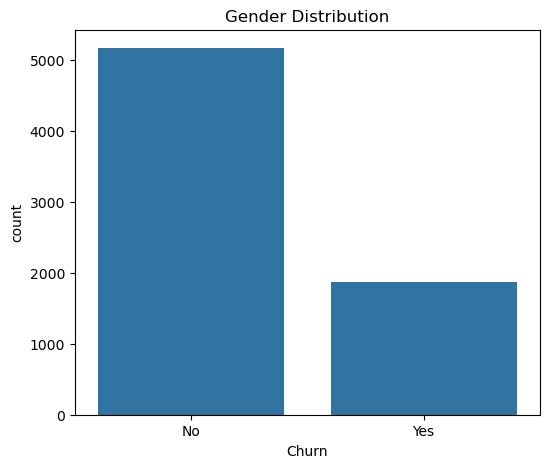

In [33]:
plt.figure(figsize=(6,5))
sns.countplot(x="Churn", data=df)
plt.title("Gender Distribution")
plt.show()

## Contract Type

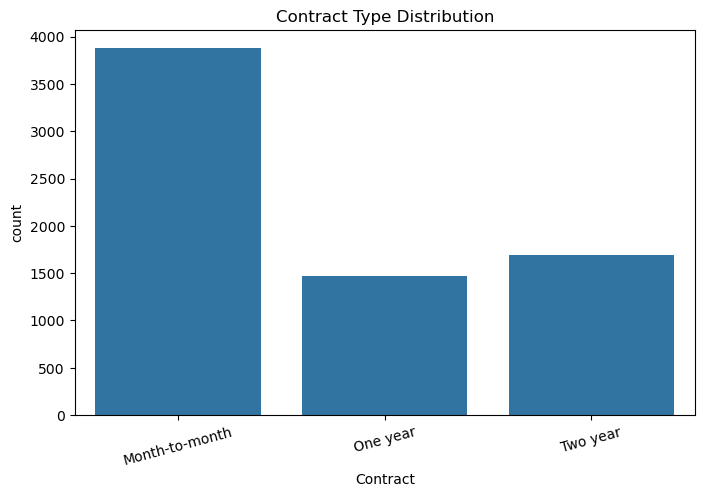

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(x="Contract", data=df)
plt.title("Contract Type Distribution")
plt.xticks(rotation=15)
plt.show()

## Internet Service

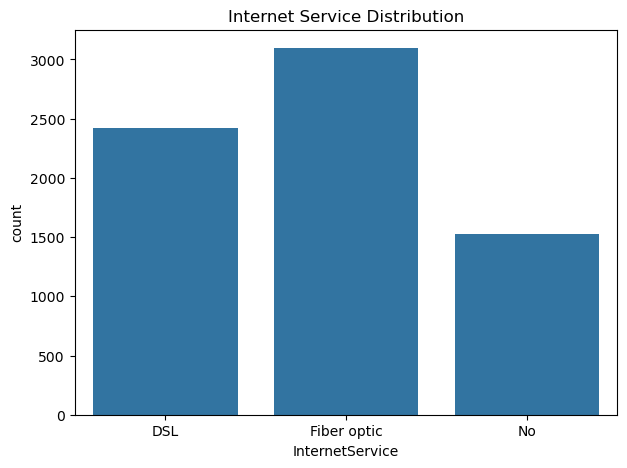

In [34]:
plt.figure(figsize=(7,5))
sns.countplot(x="InternetService", data=df)
plt.title("Internet Service Distribution")
plt.show()

## Payment Method

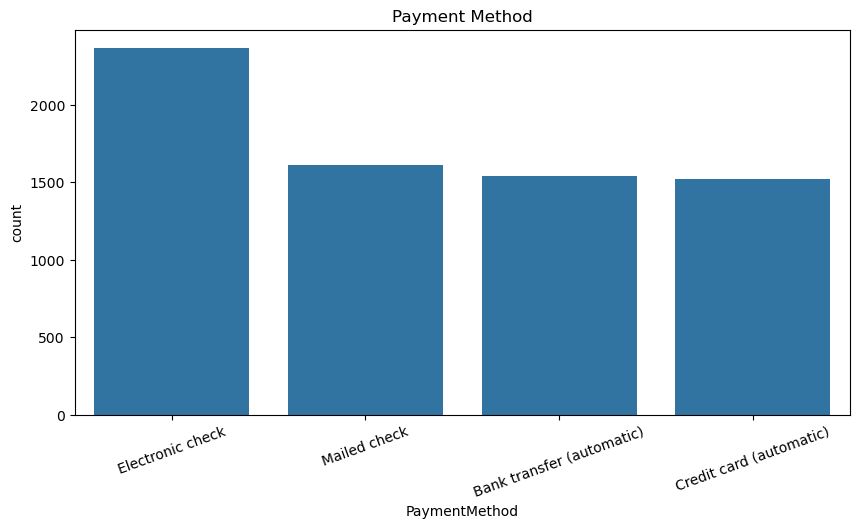

In [35]:
plt.figure(figsize=(10,5))
sns.countplot(x="PaymentMethod", data=df)
plt.xticks(rotation=20)
plt.title("Payment Method")
plt.show()

## Senior Citizen

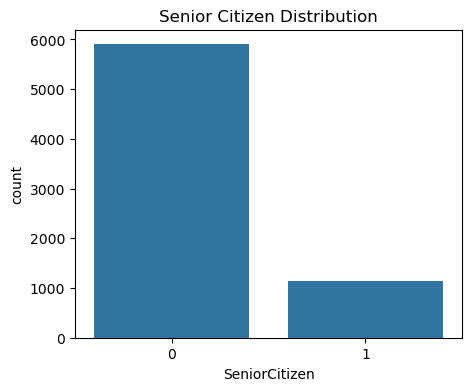

In [36]:
plt.figure(figsize=(5,4))
sns.countplot(x="SeniorCitizen", data=df)
plt.title("Senior Citizen Distribution")
plt.show()

## Monthly Charges

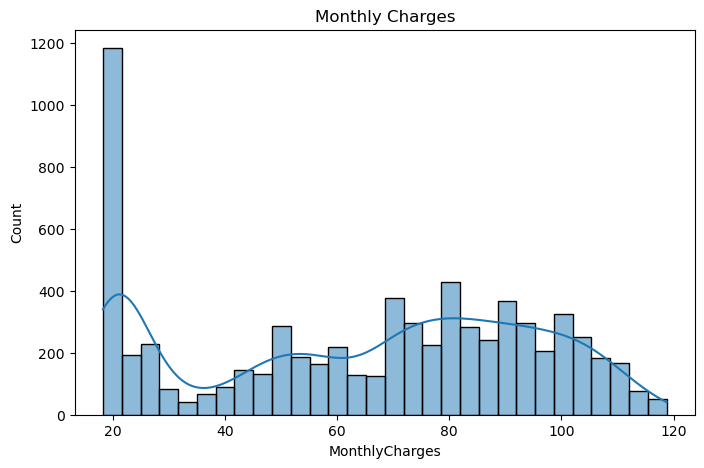

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True)
plt.title("Monthly Charges")
plt.show()

## Tenure

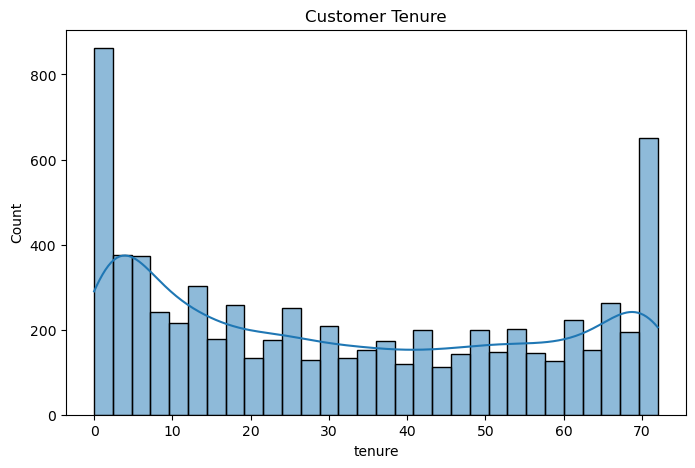

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30, kde=True)
plt.title("Customer Tenure")
plt.show()

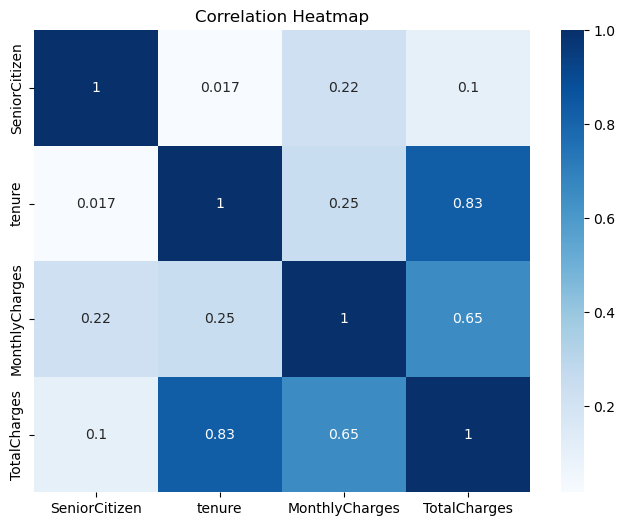

In [39]:
plt.figure(figsize=(8,6))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

## Feature Engineering

In [40]:
df["AverageMonthlySpend"] = df["TotalCharges"] / (df["tenure"] + 1)

In [41]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AverageMonthlySpend
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,14.925000
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,53.985714
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,36.050000
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.016304
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,50.550000


## Data Preprocessing

### Encode Target Variable

In [42]:
df["Churn"] = LabelEncoder().fit_transform(df["Churn"])

### Separate Features & Target

In [43]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

### Encode Categorical Variables

In [44]:
X = pd.get_dummies(X, drop_first=True)

### Train Test Split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Feature Scaling

In [46]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression

In [47]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(random_state=42)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:,1]

## Random Forest Classifier

In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

## XGBoost Classifier

In [54]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

## Accuracy, Precision, Recall & F1-Score

In [55]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

def evaluate_model(name, y_true, y_pred):

    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_true,y_pred))
    print("Precision:", precision_score(y_true,y_pred))
    print("Recall   :", recall_score(y_true,y_pred))
    print("F1 Score :", f1_score(y_true,y_pred))

    print("\nClassification Report\n")
    print(classification_report(y_true,y_pred))

## Logistic Regression Result

In [56]:
evaluate_model(
    "Logistic Regression",
    y_test,
    y_pred_log
)

Logistic Regression
Accuracy : 0.808374733853797
Precision: 0.674496644295302
Recall   : 0.5374331550802139
F1 Score : 0.5982142857142857

Classification Report

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Random Forest Result

In [57]:
evaluate_model(
    "Random Forest",
    y_test,
    y_pred_rf
)

Random Forest
Accuracy : 0.7849538679914834
Precision: 0.621160409556314
Recall   : 0.48663101604278075
F1 Score : 0.545727136431784

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



## XGBoost Result

In [58]:
evaluate_model(
    "XGBoost",
    y_test,
    y_pred_xgb
)

XGBoost
Accuracy : 0.7806955287437899
Precision: 0.6018808777429467
Recall   : 0.5133689839572193
F1 Score : 0.5541125541125541

Classification Report

              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1035
           1       0.60      0.51      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.70      0.70      1409
weighted avg       0.77      0.78      0.77      1409



## Confusion Matrix

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true,y_pred,title):

    cm = confusion_matrix(y_true,y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

## Logistic Regression

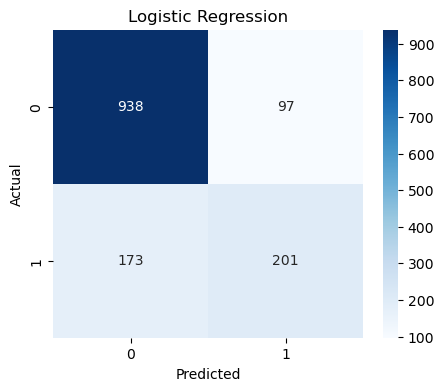

In [61]:
plot_confusion_matrix(
    y_test,
    y_pred_log,
    "Logistic Regression"
)

## Random Forest

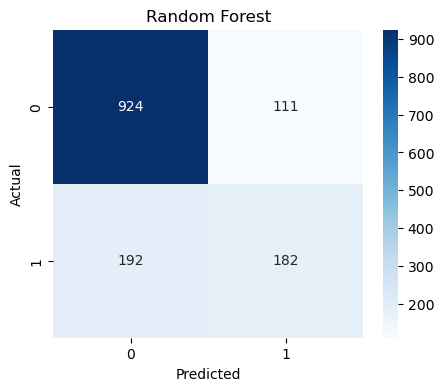

In [62]:
plot_confusion_matrix(
    y_test,
    y_pred_rf,
    "Random Forest"
)

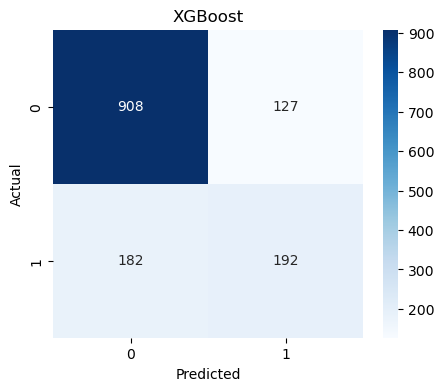

In [63]:
plot_confusion_matrix(
    y_test,
    y_pred_xgb,
    "XGBoost"
)

## ROC Curve

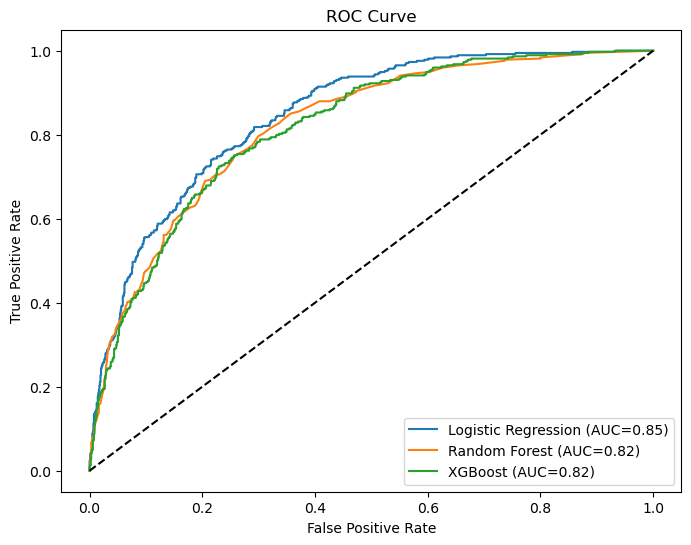

In [64]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8,6))

fpr,tpr,_=roc_curve(y_test,y_prob_log)
plt.plot(fpr,tpr,label=f"Logistic Regression (AUC={auc(fpr,tpr):.2f})")

fpr,tpr,_=roc_curve(y_test,y_prob_rf)
plt.plot(fpr,tpr,label=f"Random Forest (AUC={auc(fpr,tpr):.2f})")

fpr,tpr,_=roc_curve(y_test,y_prob_xgb)
plt.plot(fpr,tpr,label=f"XGBoost (AUC={auc(fpr,tpr):.2f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

## Feature Importance

### Random Forest

In [65]:
feature_importance = pd.DataFrame({

    "Feature":X.columns,
    "Importance":rf_model.feature_importances_

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.158456
1,tenure,0.148883
4,AverageMonthlySpend,0.136391
2,MonthlyCharges,0.134777
11,InternetService_Fiber optic,0.043855
29,PaymentMethod_Electronic check,0.035038
26,Contract_Two year,0.032726
5,gender_Male,0.024857
14,OnlineSecurity_Yes,0.023385
27,PaperlessBilling_Yes,0.023302


### Plot Feature Importance

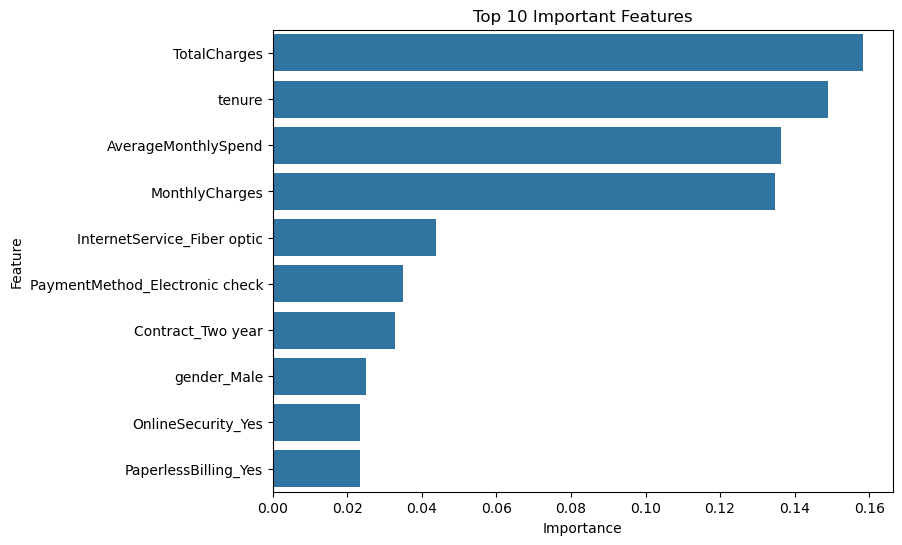

In [66]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

## Model Comparison Table

In [67]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_log),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_xgb)
    ],

    "Precision":[
        precision_score(y_test,y_pred_log),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_xgb)
    ],

    "Recall":[
        recall_score(y_test,y_pred_log),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_xgb)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_log),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_xgb)
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.808375,0.674497,0.537433,0.598214
1,Random Forest,0.784954,0.621160,0.486631,0.545727
2,XGBoost,0.780696,0.601881,0.513369,0.554113


## Best Model

In [68]:
comparison.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.808375,0.674497,0.537433,0.598214
1,Random Forest,0.784954,0.621160,0.486631,0.545727
2,XGBoost,0.780696,0.601881,0.513369,0.554113


## Business Insights

• Customers with month-to-month contracts are more likely to churn.

• Customers having higher monthly charges show a higher churn rate.

• Long-term customers (higher tenure) are less likely to leave.

• Customers using electronic check payments have relatively higher churn.

• Fiber optic internet users exhibit a higher churn rate than DSL users.

• The Random Forest/XGBoost model provides strong predictive performance for identifying customers at risk of churn.

• Businesses can reduce churn by targeting high-risk customers with personalized offers, contract upgrades, loyalty programs, and proactive customer support.

# Project Conclusion

In this project, a complete Customer Churn Prediction system was developed using the Telco Customer Churn dataset. The dataset was cleaned, preprocessed, explored through Exploratory Data Analysis (EDA), and transformed into a machine learning-ready format.

Three machine learning algorithms—Logistic Regression, Random Forest Classifier, and XGBoost Classifier—were trained and evaluated using multiple performance metrics, including Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC Curve. Feature Importance analysis was also performed to identify the factors that contribute most to customer churn.

Among the evaluated models, the best-performing model demonstrated strong predictive capability for identifying customers who are likely to leave the company. The analysis revealed that customers with month-to-month contracts, higher monthly charges, lower tenure, and electronic check payment methods are more likely to churn.

This project demonstrates the complete machine learning workflow, from data preprocessing to model evaluation, and provides valuable business insights that can help telecom companies reduce customer churn through targeted retention strategies.